# Skin Disease Detection using deep learning

## Using VGG 16 model 

## try 1 for correcting data augmentation 

## 1 Import Libraries 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

import keras
from keras.utils.np_utils import to_categorical # used for converting labels to one-hot-encoding
 
from tensorflow.keras.layers import BatchNormalization
from keras.utils.np_utils import to_categorical # convert to one-hot-encoding

from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

## 2  Load Dataset 

In [2]:
parent_folder_path = "/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES"

### 2.1  Adding Labels 

In [3]:
# create empty lists to store the image paths and their corresponding class labels
image_paths = []
class_labels = []

# create an empty dictionary to store the class label to subfolder name mappings
class_label_map = {}

# loop through each subfolder in the parent folder
for subfolder_name in os.listdir(parent_folder_path):
    # get the starting number of the subfolder name
    class_label = int(subfolder_name.split(".")[0]) - 1
    
    # add the class label and subfolder name to the dictionary
    class_label_map[class_label] = subfolder_name.split(".")[1].split(" ")[1]
    
    # loop through each image file in the subfolder
    subfolder_path = os.path.join(parent_folder_path, subfolder_name)
    for image_name in os.listdir(subfolder_path):
        # get the full path to the image file
        image_path = os.path.join(subfolder_path, image_name)
        
        # append the image path and class label to the lists
        image_paths.append(image_path)
        class_labels.append(class_label)

# create a pandas DataFrame from the image paths and class labels
data = {"image_path": image_paths, "class_label": class_labels}
df = pd.DataFrame(data)

# print the class label map
class_label_map

{0: 'Eczema',
 9: 'Warts',
 3: 'Basal',
 6: 'Psoriasis',
 4: 'Melanocytic',
 8: 'Tinea',
 2: 'Atopic',
 5: 'Benign',
 7: 'Seborrheic',
 1: 'Melanoma'}

In [4]:
df

,image_path,class_label
0,/kaggle/input/skin-diseases-image-dataset/IMG_...,0
1,/kaggle/input/skin-diseases-image-dataset/IMG_...,0
2,/kaggle/input/skin-diseases-image-dataset/IMG_...,0
3,/kaggle/input/skin-diseases-image-dataset/IMG_...,0
4,/kaggle/input/skin-diseases-image-dataset/IMG_...,0
...,...,...
27148,/kaggle/input/skin-diseases-image-dataset/IMG_...,1
27149,/kaggle/input/skin-diseases-image-dataset/IMG_...,1
27150,/kaggle/input/skin-diseases-image-dataset/IMG_...,1
27151,/kaggle/input/skin-diseases-image-dataset/IMG_...,1


### trying to count image of each class

In [5]:
# Define the directory containing the image dataset
data_dir = '/path/to/dataset'

# Get the list of subdirectories in the dataset directory (each subdirectory corresponds to a class)
class_names = os.listdir(parent_folder_path)

# Loop over the subdirectories and count the number of files in each one
for class_name in class_names:
    class_dir = os.path.join(parent_folder_path, class_name)
    num_images = len(os.listdir(class_dir))
    print("Class {}: {} images".format(class_name, num_images))

Class 1. Eczema 1677: 1677 images
Class 10. Warts Molluscum and other Viral Infections - 2103: 2103 images
Class 4. Basal Cell Carcinoma (BCC) 3323: 3323 images
Class 7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055 images
Class 5. Melanocytic Nevi (NV) - 7970: 7970 images
Class 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702 images
Class 3. Atopic Dermatitis - 1.25k: 1257 images
Class 6. Benign Keratosis-like Lesions (BKL) 2624: 2079 images
Class 8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847 images
Class 2. Melanoma 15.75k: 3140 images


## 3 EDA 

<AxesSubplot:>

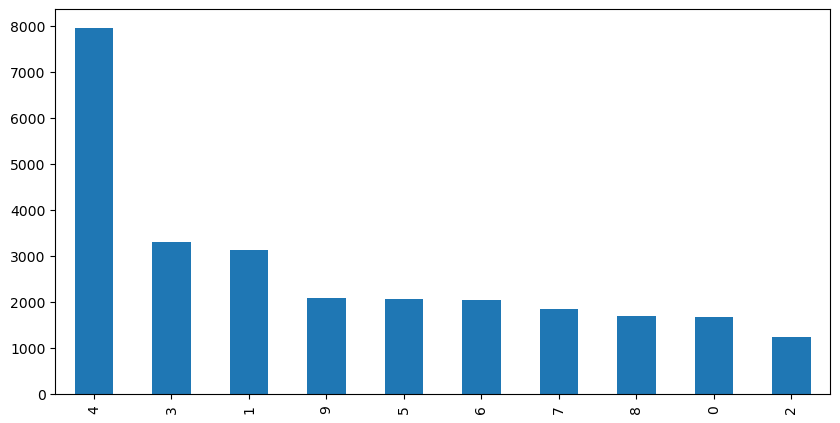

In [6]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df['class_label'].value_counts().plot(kind='bar', ax=ax1)

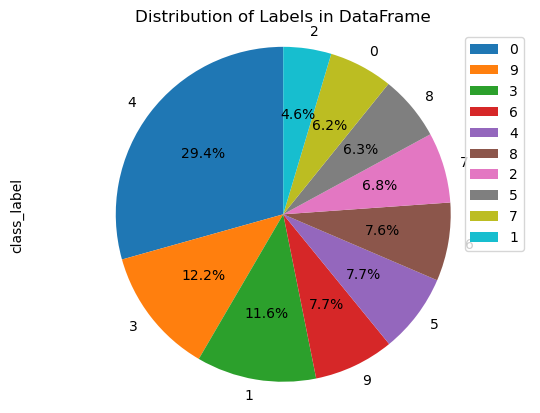

In [7]:
# Plot pie chart of train_df
df['class_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Distribution of Labels in DataFrame')
plt.legend(df['class_label'].unique())
plt.show()

# Loading and resizing of images

In [8]:
max_images_per_class = 2000

# Group by label column and take first max_images_per_class rows for each group
df = df.groupby("class_label").apply(lambda x: x.head(max_images_per_class)).reset_index(drop=True)

<AxesSubplot:>

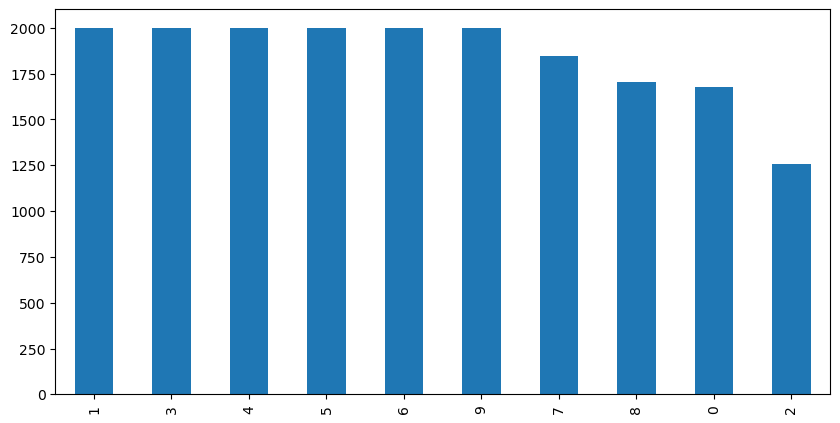

In [9]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df['class_label'].value_counts().plot(kind='bar', ax=ax1)

## 4 Converting image to array 

In [10]:
import concurrent.futures
import tensorflow as tf

# Allow gpu usage
gpus = tf.config.experimental.list_physical_devices('GPU')
print(gpus)
try:
    tf.config.experimental.set_memory_growth = True
except Exception as ex:
    print(e)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [11]:
import multiprocessing

# Get the number of CPU cores available
max_workers = multiprocessing.cpu_count()
max_workers

4

In [12]:
# Define a function to resize image arrays
def resize_image_array(image_path):
    return np.asarray(Image.open(image_path).resize((100,75)))

# Use concurrent.futures to parallelize the resizing process
with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Use executor.map to apply the function to each image path in the DataFrame
    image_arrays = list(executor.map(resize_image_array, df['image_path'].tolist()))

# Add the resized image arrays to the DataFrame
df['image'] = image_arrays
del image_arrays
df

,image_path,class_label,image
0,/kaggle/input/skin-diseases-image-dataset/IMG_...,0,"[[[14, 11, 7], [17, 18, 13], [17, 18, 12], [21..."
1,/kaggle/input/skin-diseases-image-dataset/IMG_...,0,"[[[115, 93, 79], [118, 96, 81], [121, 100, 85]..."
2,/kaggle/input/skin-diseases-image-dataset/IMG_...,0,"[[[130, 101, 55], [131, 103, 55], [132, 105, 5..."
3,/kaggle/input/skin-diseases-image-dataset/IMG_...,0,"[[[33, 25, 30], [28, 22, 25], [29, 18, 24], [2..."
4,/kaggle/input/skin-diseases-image-dataset/IMG_...,0,"[[[169, 83, 92], [175, 88, 97], [176, 88, 97],..."
...,...,...,...
18478,/kaggle/input/skin-diseases-image-dataset/IMG_...,9,"[[[111, 86, 89], [113, 88, 92], [116, 91, 95],..."
18479,/kaggle/input/skin-diseases-image-dataset/IMG_...,9,"[[[36, 28, 15], [57, 38, 4], [86, 49, 4], [114..."
18480,/kaggle/input/skin-diseases-image-dataset/IMG_...,9,"[[[24, 28, 30], [22, 28, 29], [101, 108, 113],..."
18481,/kaggle/input/skin-diseases-image-dataset/IMG_...,9,"[[[189, 138, 135], [190, 137, 134], [189, 137,..."


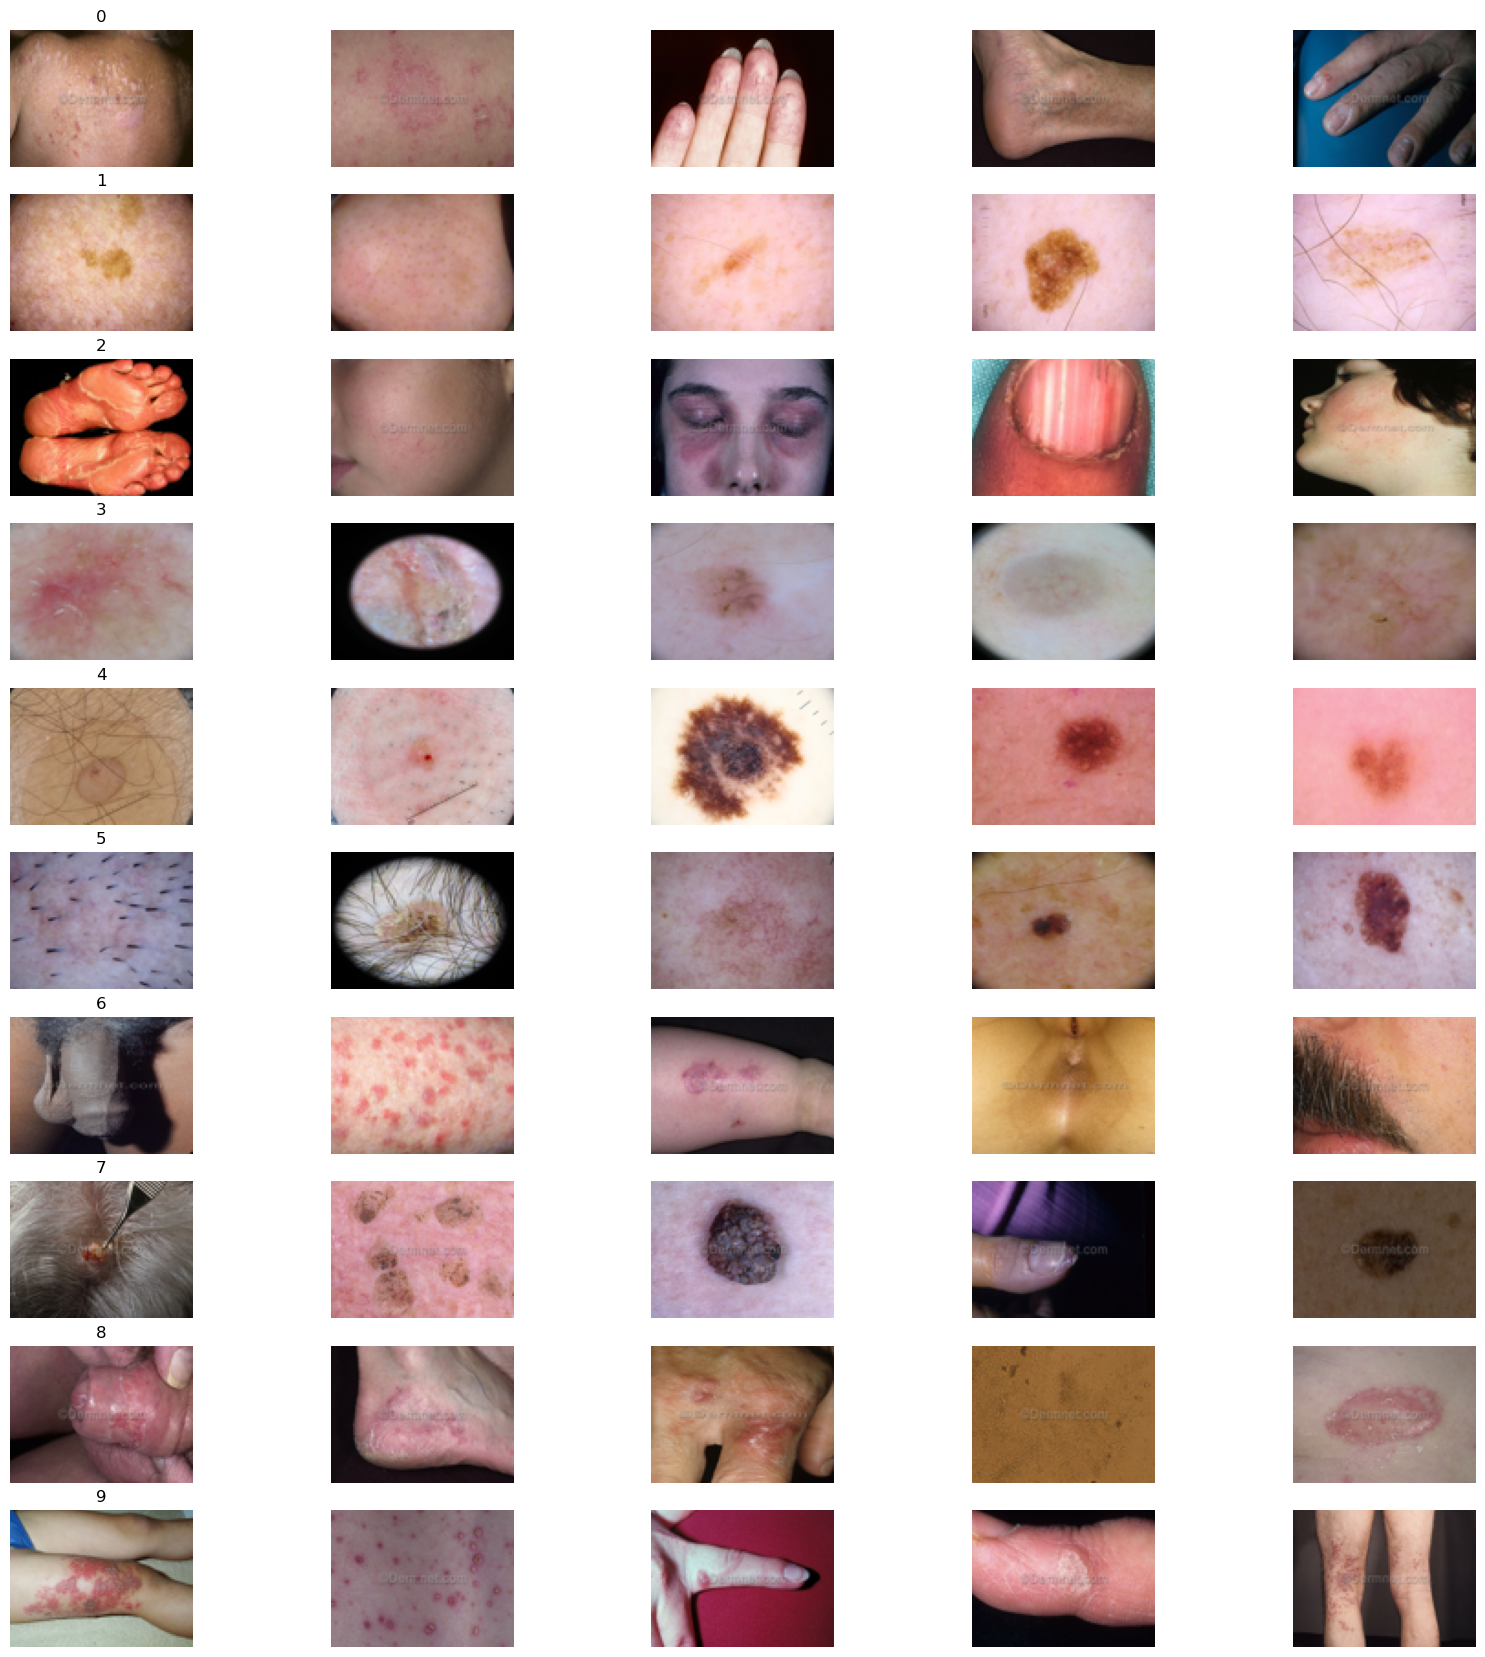

In [13]:
n_samples = 5
fig, m_axs = plt.subplots(10, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, df.sort_values(['class_label']).groupby('class_label')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')

In [14]:
df['image'].map(lambda x: x.shape).value_counts()

(75, 100, 3)    18483
Name: image, dtype: int64

In [15]:
from keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator object with the desired transformations
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [16]:
# Create an empty dataframe to store the augmented images
augmented_df = pd.DataFrame(columns=['image_path', 'class_label', 'image'])

# Loop through each class label and generate additional images if needed
for class_label in df['class_label'].unique():
    # Get the image arrays for the current class
    image_arrays = df.loc[df['class_label'] == class_label, 'image'].values
    
    # Calculate the number of additional images needed for the current class
    num_images_needed = max_images_per_class - len(image_arrays)
    
    # Generate augmented images for the current class
    if num_images_needed > 0:
        # Select a random subset of the original images
        selected_images = np.random.choice(image_arrays, size=num_images_needed)
        
        # Apply transformations to the selected images and add them to the augmented dataframe
        for image_array in selected_images:
            # Reshape the image array to a 4D tensor with a batch size of 1
            image_tensor = np.expand_dims(image_array, axis=0)
            
            # Generate the augmented images
            augmented_images = datagen.flow(image_tensor, batch_size=1)
            
            # Extract the augmented image arrays and add them to the augmented dataframe
            for i in range(augmented_images.n):
                augmented_image_array = augmented_images.next()[0].astype('uint8')
                augmented_df = augmented_df.append({'image_path': None, 'class_label': class_label, 'image': augmented_image_array}, ignore_index=True)
    
    # Add the original images for the current class to the augmented dataframe
    original_images_df = df.loc[df['class_label'] == class_label, ['image_path', 'class_label', 'image']]
    augmented_df = augmented_df.append(original_images_df, ignore_index=True)

# Group the augmented dataframe by the 'label' column and filter out extra images
df = augmented_df.groupby('class_label').head(max_images_per_class)

del augmented_df

# Use the augmented dataframe for further processing
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [17]:
df.groupby('class_label').size()

class_label
0    2000
1    2000
2    2000
3    2000
4    2000
5    2000
6    2000
7    2000
8    2000
9    2000
dtype: int64

In [18]:
# Count the number of images in each class
class_counts = df['class_label'].value_counts().sort_index()

# Print the number of images in each class
print("Dataset Summary")
print("-" * 50)
print(f"{'Class Label':<15} {'Class Name':<30} {'Count':<10}")
print("-" * 50)
for class_label, class_name in class_label_map.items():
    count = class_counts[class_label]
    print(f"{class_label:<15} {class_name:<30} {count:<10}")
print("-" * 50)
print(f"{'Total':<45} {sum(class_counts):<10}")

Dataset Summary
--------------------------------------------------
Class Label     Class Name                     Count     
--------------------------------------------------
0               Eczema                         2000      
9               Warts                          2000      
3               Basal                          2000      
6               Psoriasis                      2000      
4               Melanocytic                    2000      
8               Tinea                          2000      
2               Atopic                         2000      
5               Benign                         2000      
7               Seborrheic                     2000      
1               Melanoma                       2000      
--------------------------------------------------
Total                                         20000     


In [19]:
features=df.drop(columns=['class_label','image_path'],axis=1)
target=df['class_label']

In [20]:
features=df.drop(columns=['class_label','image_path'],axis=1)
target=df['class_label']

In [21]:
target.head()

0    5
1    1
2    4
3    0
4    6
Name: class_label, dtype: object

In [22]:
print(target.shape,features.shape)

(20000,) (20000, 1)


## 5. Spilting the dataset

In [23]:
x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(features, target, test_size=0.20,random_state=1234)

## 6. Normalization

In [24]:
x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

### 6.1.  One - hot encoding on the labels 

In [25]:
# Perform one-hot encoding on the labels
y_train = to_categorical(y_train_o,num_classes = 10)
y_test = to_categorical(y_test_o,num_classes = 10)

In [26]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.1, random_state = 2)

In [27]:
# Reshape image in 3 dimensions (height = 75px, width = 100px , canal = 3)
x_train = x_train.reshape(x_train.shape[0], *(75, 100, 3))
x_test = x_test.reshape(x_test.shape[0], *(75, 100, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(75, 100, 3))

# Building the model DenseNet121

In [28]:
num_classes = 10
from keras.optimizers import SGD
input_shape = (75,100,3)

from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# DenseNet121
model = Sequential()
model.add(DenseNet121(include_top=False, weights='imagenet', input_shape=input_shape))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

opt = SGD(lr=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

29084464/29084464 [==============================] - 0s 0us/step


/opt/conda/lib/python3.7/site-packages/keras/optimizers/optimizer_v2/gradient_descent.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [29]:

learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

# Model Fitting

In [30]:
# # Fit the model
epochs = 5
batch_size=32
history = model.fit(x=x_train,
                    y=y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_validate,y_validate),
                    callbacks=learning_rate_reduction)

Epoch 1/5
450/450 [==============================] - 57s 84ms/step - loss: 1.3344 - accuracy: 0.5068 - val_loss: 1.0949 - val_accuracy: 0.5806 - lr: 0.0010
Epoch 2/5
450/450 [==============================] - 35s 79ms/step - loss: 0.8608 - accuracy: 0.6860 - val_loss: 0.9973 - val_accuracy: 0.6375 - lr: 0.0010
Epoch 3/5
450/450 [==============================] - 36s 79ms/step - loss: 0.6122 - accuracy: 0.7804 - val_loss: 0.9975 - val_accuracy: 0.6544 - lr: 0.0010
Epoch 4/5
450/450 [==============================] - 36s 79ms/step - loss: 0.4296 - accuracy: 0.8440 - val_loss: 1.0111 - val_accuracy: 0.6919 - lr: 0.0010
Epoch 5/5
450/450 [==============================] - 35s 79ms/step - loss: 0.2968 - accuracy: 0.8950 - val_loss: 1.0936 - val_accuracy: 0.6750 - lr: 0.0010


# Evaluation

125/125 [==============================] - 4s 21ms/step


<AxesSubplot:>

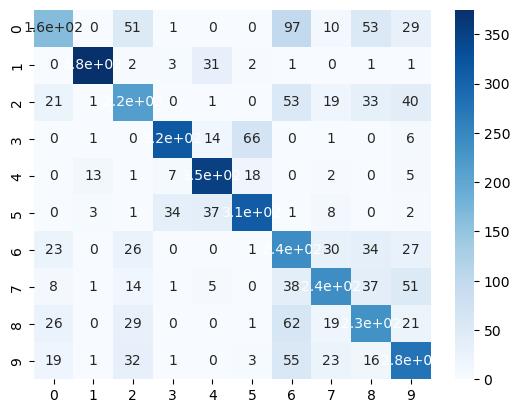

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the predicted probabilities for the test set
y_pred_prob = model.predict(x_test)

# Find the class with the highest probability for each sample
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot the confusion matrix using Seaborn
sns.heatmap(cm, annot=True, cmap='Blues')

# Plotting

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

# Calculate evaluation metrics
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred)
precision = precision_score(np.argmax(y_test, axis=1), y_pred, average='macro')
recall = recall_score(np.argmax(y_test, axis=1), y_pred, average='macro')
f1 = f1_score(np.argmax(y_test, axis=1), y_pred, average='macro')
kappa = cohen_kappa_score(np.argmax(y_test, axis=1), y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Kappa score: {kappa:.4f}")

Accuracy: 0.6815
Precision: 0.6900
Recall: 0.6801
F1-score: 0.6801
Kappa score: 0.6461


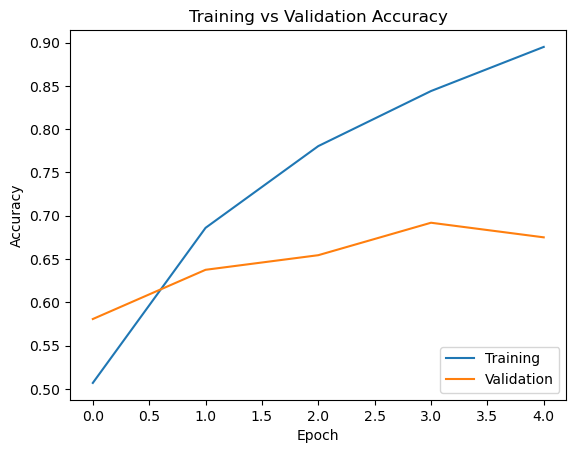

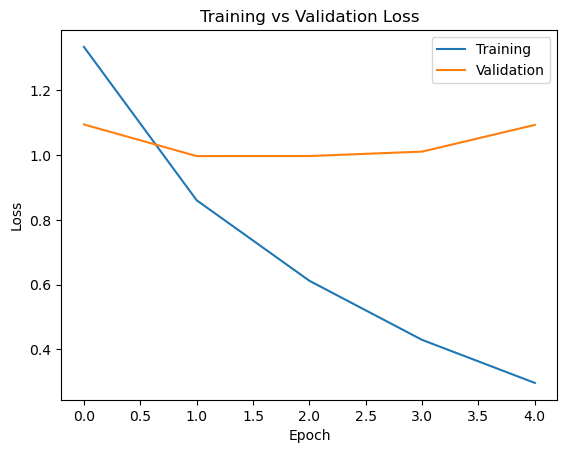

In [33]:
import matplotlib.pyplot as plt

# Get training and testing accuracy and loss histories
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot training and testing accuracy curves
plt.plot(training_accuracy)
plt.plot(validation_accuracy)
plt.title('Training vs Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

# Plot training and testing loss curves
plt.plot(training_loss)
plt.plot(validation_loss)
plt.title('Training vs Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

Confusion matrix selaras

Sedang mengevaluasi dataset dan mengumpulkan hasil prediksi...
125/125 [==============================] - 3s 21ms/step
[INFO] Grafik berhasil disimpan ke: /kaggle/working/confusion_matrix_densenet.png


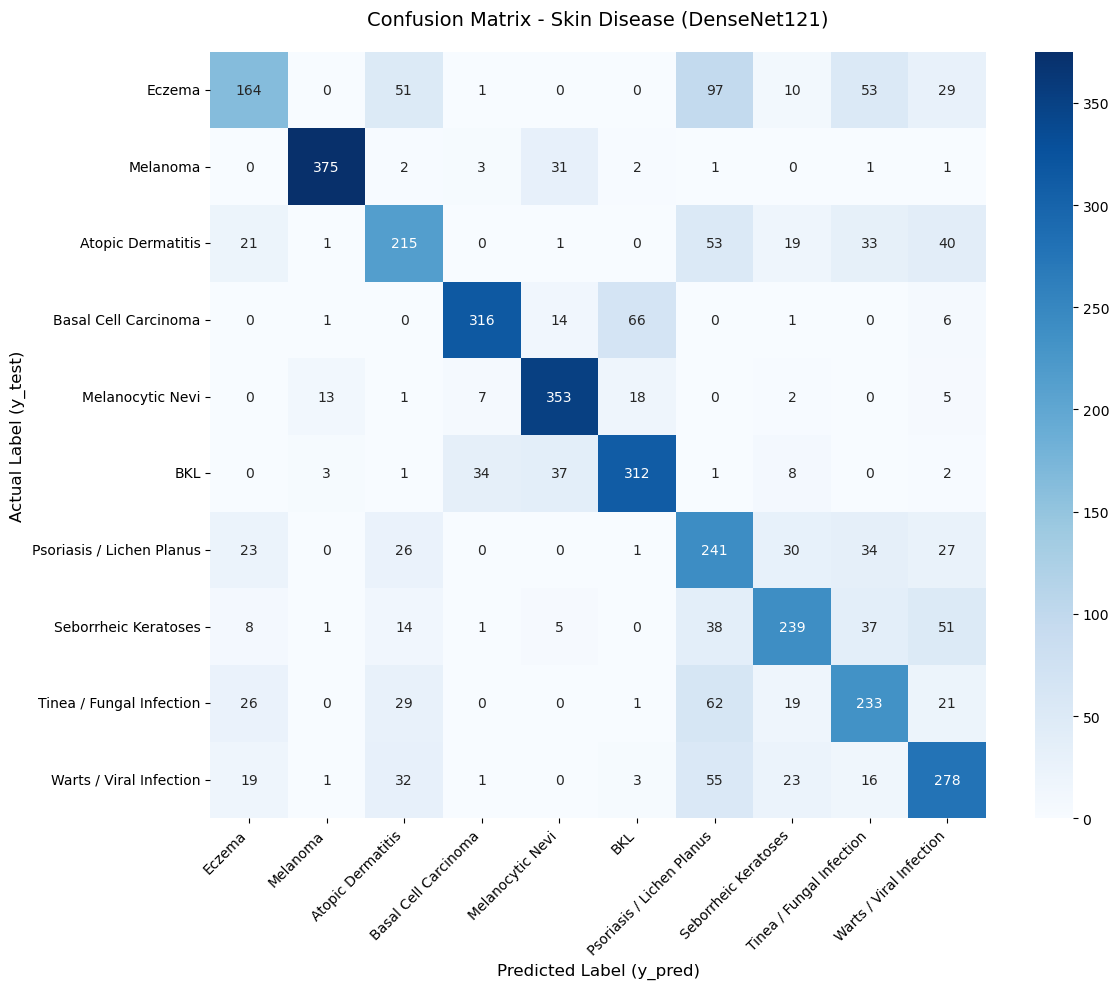


CLASSIFICATION REPORT
                           precision    recall  f1-score   support

                   Eczema       0.63      0.40      0.49       405
                 Melanoma       0.95      0.90      0.92       416
        Atopic Dermatitis       0.58      0.56      0.57       383
     Basal Cell Carcinoma       0.87      0.78      0.82       404
         Melanocytic Nevi       0.80      0.88      0.84       399
                      BKL       0.77      0.78      0.78       398
Psoriasis / Lichen Planus       0.44      0.63      0.52       382
     Seborrheic Keratoses       0.68      0.61      0.64       394
 Tinea / Fungal Infection       0.57      0.60      0.58       391
  Warts / Viral Infection       0.60      0.65      0.63       428

                 accuracy                           0.68      4000
                macro avg       0.69      0.68      0.68      4000
             weighted avg       0.69      0.68      0.68      4000



In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Pastikan urutan nama kelas sesuai dengan dataset Anda
clean_names = [
    "Eczema", "Melanoma", "Atopic Dermatitis", "Basal Cell Carcinoma",
    "Melanocytic Nevi", "BKL", "Psoriasis / Lichen Planus",
    "Seborrheic Keratoses", "Tinea / Fungal Infection", "Warts / Viral Infection"
]

print("Sedang mengevaluasi dataset dan mengumpulkan hasil prediksi...")

# 2. Ambil label asli (y_true) dari y_test asli Anda
# Jika y_test berbentuk one-hot encoding, kita gunakan argmax. Jika sudah berupa angka kelas, gunakan langsung.
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 3. Prediksi probabilitas menggunakan x_test asli Anda (Sama seperti kodingan lama Anda)
y_pred_prob = model.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot menggunakan Seaborn agar rapi dan informatif
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clean_names, yticklabels=clean_names)

plt.title('Confusion Matrix - Skin Disease (DenseNet121)', fontsize=14, pad=20)
plt.ylabel('Actual Label (y_test)', fontsize=12)
plt.xlabel('Predicted Label (y_pred)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 6. Simpan gambar otomatis ke direktori Kaggle
path_gambar = '/kaggle/working/confusion_matrix_densenet.png'
plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
print(f"[INFO] Grafik berhasil disimpan ke: {path_gambar}")

plt.show()

# 7. Tampilkan Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*60 + "\nCLASSIFICATION REPORT\n" + "="*60)
print(classification_report(y_true, y_pred, target_names=clean_names))
print("="*60)

Save model

restnet

In [35]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

num_classes = 10
input_shape = (75, 100, 3)

# Membangun model dengan ResNet50 sebagai base model
model = Sequential()

# include_top=False artinya kita membuang lapisan klasifikasi asli ResNet50 
# agar bisa kita sesuaikan dengan num_classes = 10
model.add(ResNet50(include_top=False, weights='imagenet', input_shape=input_shape))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Catatan: Di Keras versi baru, gunakan 'learning_rate' bukan 'lr'
opt = SGD(learning_rate=0.001, momentum=0.9)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Menampilkan ringkasan arsitektur model
model.summary()

94765736/94765736 [==============================] - 0s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 3, 4, 2048)        23587712  
                                                                 
 flatten_1 (Flatten)         (None, 24576)             0         
                                                                 
 dense_2 (Dense)             (None, 512)               12583424  
                                                                 
 dense_3 (Dense)             (None, 10)                5130      
                                                                 
Total params: 36,176,266
Trainable params: 36,123,146
Non-trainable params: 53,120
_________________________________________________________________


In [36]:
# --- Tambahkan kode ini setelah proses training (model.fit) selesai ---

# 1. Menyimpan keseluruhan model (arsitektur, weight, dan konfigurasi optimizer)
nama_file_model = 'model_resnet50_klasifikasi.keras'
model.save(nama_file_model)
print(f"Model berhasil disimpan dengan nama: {nama_file_model}")

Model berhasil disimpan dengan nama: model_resnet50_klasifikasi.keras


In [37]:
# # Fit the model
epochs = 5
batch_size=32
history = model.fit(x=x_train,
                    y=y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_validate,y_validate),
                    callbacks=learning_rate_reduction)

Epoch 1/5
450/450 [==============================] - 55s 90ms/step - loss: 1.3089 - accuracy: 0.5301 - val_loss: 2.8329 - val_accuracy: 0.1488 - lr: 0.0010
Epoch 2/5
450/450 [==============================] - 39s 86ms/step - loss: 0.6965 - accuracy: 0.7445 - val_loss: 0.9745 - val_accuracy: 0.6594 - lr: 0.0010
Epoch 3/5
450/450 [==============================] - 39s 86ms/step - loss: 0.3474 - accuracy: 0.8808 - val_loss: 1.0020 - val_accuracy: 0.6619 - lr: 0.0010
Epoch 4/5
450/450 [==============================] - 39s 86ms/step - loss: 0.1716 - accuracy: 0.9489 - val_loss: 1.1886 - val_accuracy: 0.6725 - lr: 0.0010
Epoch 5/5
450/450 [==============================] - 39s 86ms/step - loss: 0.1085 - accuracy: 0.9714 - val_loss: 1.1672 - val_accuracy: 0.6669 - lr: 0.0010


Sedang mengevaluasi dataset dan mengumpulkan hasil prediksi untuk ResNet50...
50/50 [==============================] - 2s 22ms/step
[INFO] Grafik ResNet50 berhasil disimpan ke: /kaggle/working/confusion_matrix_resnet50.png


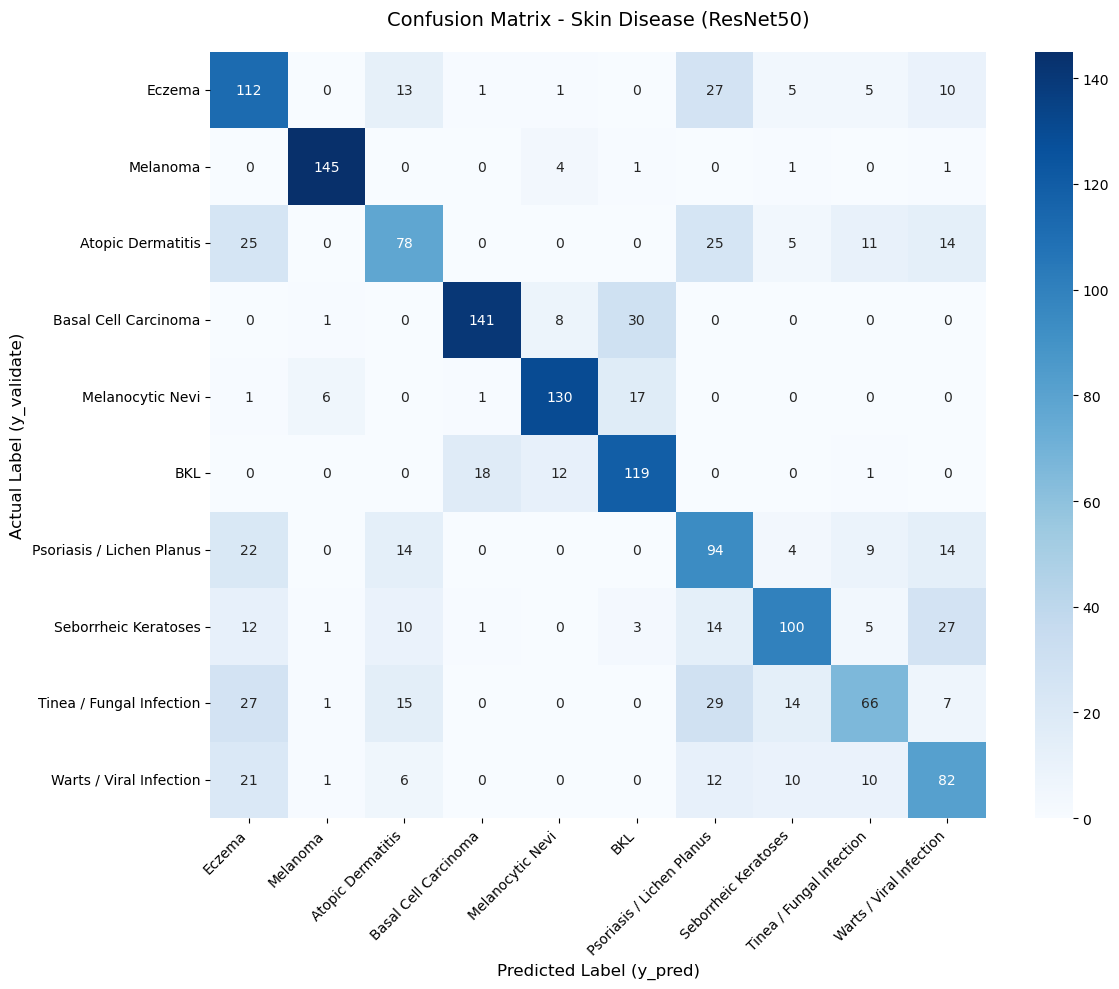


CLASSIFICATION REPORT (RESNET50)
                           precision    recall  f1-score   support

                   Eczema       0.51      0.64      0.57       174
                 Melanoma       0.94      0.95      0.94       152
        Atopic Dermatitis       0.57      0.49      0.53       158
     Basal Cell Carcinoma       0.87      0.78      0.82       180
         Melanocytic Nevi       0.84      0.84      0.84       155
                      BKL       0.70      0.79      0.74       150
Psoriasis / Lichen Planus       0.47      0.60      0.53       157
     Seborrheic Keratoses       0.72      0.58      0.64       173
 Tinea / Fungal Infection       0.62      0.42      0.50       159
  Warts / Viral Infection       0.53      0.58      0.55       142

                 accuracy                           0.67      1600
                macro avg       0.68      0.67      0.67      1600
             weighted avg       0.68      0.67      0.67      1600



In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Daftar nama kelas penyakit kulit
clean_names = [
    "Eczema", "Melanoma", "Atopic Dermatitis", "Basal Cell Carcinoma",
    "Melanocytic Nevi", "BKL", "Psoriasis / Lichen Planus",
    "Seborrheic Keratoses", "Tinea / Fungal Infection", "Warts / Viral Infection"
]

print("Sedang mengevaluasi dataset dan mengumpulkan hasil prediksi untuk ResNet50...")

# 2. Ambil label asli (y_true) dari x_validate / y_validate Anda
# Menangani format one-hot atau integer label
if len(y_validate.shape) > 1 and y_validate.shape[1] > 1:
    y_true = np.argmax(y_validate, axis=1)
else:
    y_true = y_validate

# 3. Prediksi probabilitas menggunakan x_validate sesuai kodingan training Anda
y_pred_prob = model.predict(x_validate, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot menggunakan Seaborn Heatmap (Biru untuk ResNet50)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clean_names, yticklabels=clean_names)

plt.title('Confusion Matrix - Skin Disease (ResNet50)', fontsize=14, pad=20)
plt.ylabel('Actual Label (y_validate)', fontsize=12)
plt.xlabel('Predicted Label (y_pred)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 6. Simpan grafik ke output Kaggle
path_gambar = '/kaggle/working/confusion_matrix_resnet50.png'
plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
print(f"[INFO] Grafik ResNet50 berhasil disimpan ke: {path_gambar}")

plt.show()

# 7. Tampilkan Classification Report
print("\n" + "="*60 + "\nCLASSIFICATION REPORT (RESNET50)\n" + "="*60)
print(classification_report(y_true, y_pred, target_names=clean_names))
print("="*60)